In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1. Dataset
x = np.array([1,2,3,4,5,5])

# 2. Mean, Variance, Standard Deviation
mean_x = np.mean(x)
var_x = np.var(x, ddof=1)   # sample variance ddof= 0
std_x = np.std(x, ddof=1)   # sample standard deviation ddof= 0 
mean_x
var_x 
std_x


1.632993161855452

±1 SD 1.70 to 4.97 → 3/6 observations
±2 SD 0.07 to 6.60 → 6/6 observations
±3 SD -1.57 to 8.23 → 6/6 observations


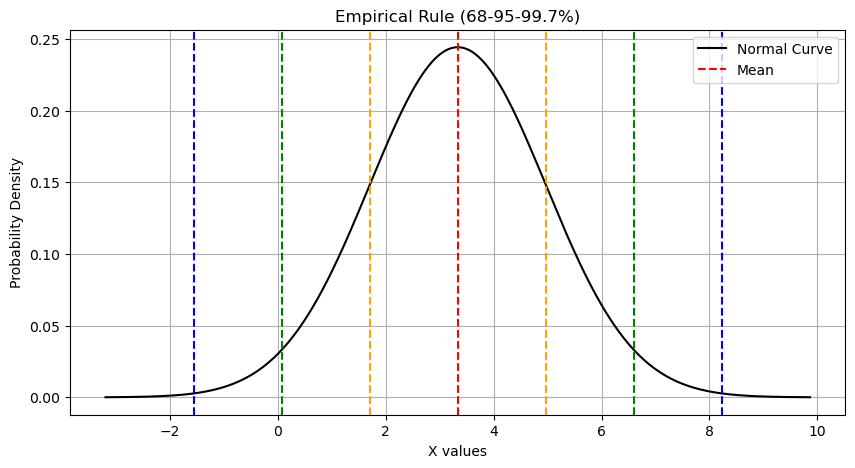

In [6]:

# 3. Empirical Rule (68-95-99.7%)
# Ranges
ranges = {
    "±1 SD": (mean_x - std_x, mean_x + std_x),
    "±2 SD": (mean_x - 2*std_x, mean_x + 2*std_x),
    "±3 SD": (mean_x - 3*std_x, mean_x + 3*std_x)
}

# Count how many values fall inside each range
for label, (low, high) in ranges.items():
    count = np.sum((x >= low) & (x <= high))
    print(f"{label} {low:.2f} to {high:.2f} → {count}/{len(x)} observations")

# 4. Plot Normal Distribution with SD lines
x_vals = np.linspace(mean_x - 4*std_x, mean_x + 4*std_x, 1000)
y_vals = (1 / (std_x * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_vals - mean_x) / std_x) ** 2)

plt.figure(figsize=(10,5))
plt.plot(x_vals, y_vals, color='black', label='Normal Curve')
plt.axvline(mean_x, color='red', linestyle='--', label='Mean')

colors = {"±1 SD":"orange", "±2 SD":"green", "±3 SD":"blue"}
for label, (low, high) in ranges.items():
    plt.axvline(low, color=colors[label], linestyle='--', label=label if "low" not in locals() else "")
    plt.axvline(high, color=colors[label], linestyle='--')

plt.title("Empirical Rule (68-95-99.7%)")
plt.xlabel("X values")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()


In [7]:
import numpy as np

# Dataset
x = np.array([1, 2, 3, 4, 5, 5])

# Mean
mean_x = np.mean(x)
print(f"Mean: {mean_x:.2f}")

# Population Variance and Std (ddof=0)
pop_var = np.var(x, ddof=0)
pop_std = np.std(x, ddof=0)

# Sample Variance and Std (ddof=1)
samp_var = np.var(x, ddof=1)
samp_std = np.std(x, ddof=1)

print("\nUsing ddof=0 → Population formulas (divide by N)")
print(f"Population Variance: {pop_var:.3f}")
print(f"Population Std Dev: {pop_std:.3f}")

print("\nUsing ddof=1 → Sample formulas (divide by N-1)")
print(f"Sample Variance: {samp_var:.3f}")
print(f"Sample Std Dev: {samp_std:.3f}")


Mean: 3.33

Using ddof=0 → Population formulas (divide by N)
Population Variance: 2.222
Population Std Dev: 1.491

Using ddof=1 → Sample formulas (divide by N-1)
Sample Variance: 2.667
Sample Std Dev: 1.633


### **`VC_Startups`**

In [8]:
# importing libraries
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')

In [9]:

# Basic statistics on the 'Profit' column
profit = df['Profit']

# Range = Max - Min
profit_range = profit.max() - profit.min()

# Variance (sample, ddof=1)
profit_variance = profit.var()

# Standard Deviation (sample, ddof=1)
profit_std = profit.std()

# Display the results
print(f"Profit Range: {profit_range}")
print(f"Profit Variance: {profit_variance}")
print(f"Profit Standard Deviation: {profit_std}")

Profit Range: 177580.43
Profit Variance: 1624588173.411208
Profit Standard Deviation: 40306.18033765055


## **`IQR`**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your data as a pandas Series
data = pd.Series([1, 2, 3, 4, 5, 6, 5, 6, 7, 8, 8, 8, 8, 8, 9, 9, 10, 11, 11, 100])

In [4]:
Q1 = data.quantile(0.25)  # 25th percentile
Q2 = data.quantile(0.50)  # 50th percentile (Median)
Q3 = data.quantile(0.75)  # 75th percentile
Q1
Q2
Q3


9.0

In [5]:
# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1
IQR

4.0

In [7]:
lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR
lower_fence 
higher_fence

15.0

Dataset: [1, 2, 3, 4, 5, 6, 5, 6, 7, 8, 8, 8, 8, 8, 9, 9, 10, 11, 11, 100]
Q1 (25th Percentile): 5.0
Q2 (50th Percentile, Median): 8.0
Q3 (75th Percentile): 9.0
IQR (Interquartile Range): 4.0
Lower Fence: -1.0
Higher Fence: 15.0
Outliers: [100]




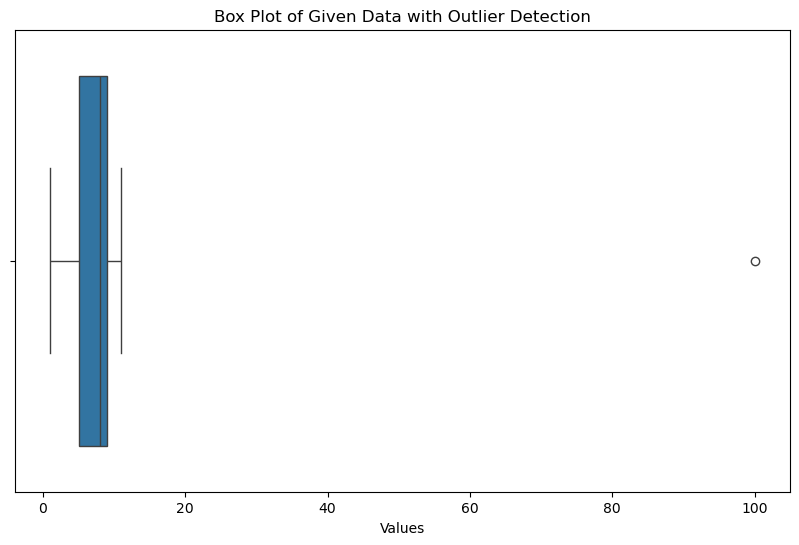

In [8]:


# Print the results
print(f"Dataset: {data.tolist()}")
print(f"Q1 (25th Percentile): {Q1}")
print(f"Q2 (50th Percentile, Median): {Q2}")
print(f"Q3 (75th Percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")
print(f"Lower Fence: {lower_fence}")
print(f"Higher Fence: {higher_fence}")

# Identify the outliers
outliers = data[(data < lower_fence) | (data > higher_fence)]
print(f"Outliers: {outliers.tolist()}")
print("\n" + "="*30 + "\n") # Separator for clarity

# --- Box Plot Visualization ---

# Using the same 'data' Series for the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=data)  # 'x=' specifies the data for a horizontal box plot directly

# Add titles and labels
plt.title('Box Plot of Given Data with Outlier Detection')
plt.xlabel('Values')

# Show the plot
plt.show()

In [9]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy import stats
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/Loan-Approval-Prediction (1).csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [10]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

<Axes: >

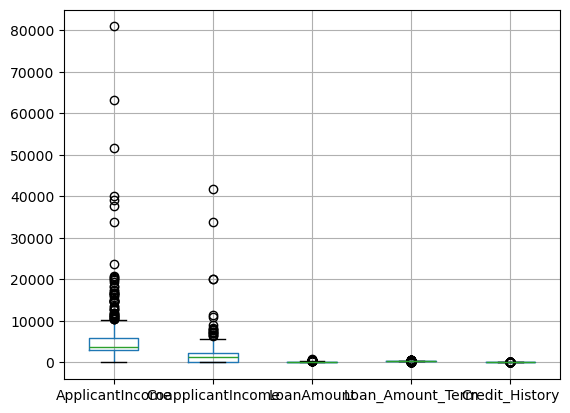

In [11]:
df.boxplot()

<Axes: >

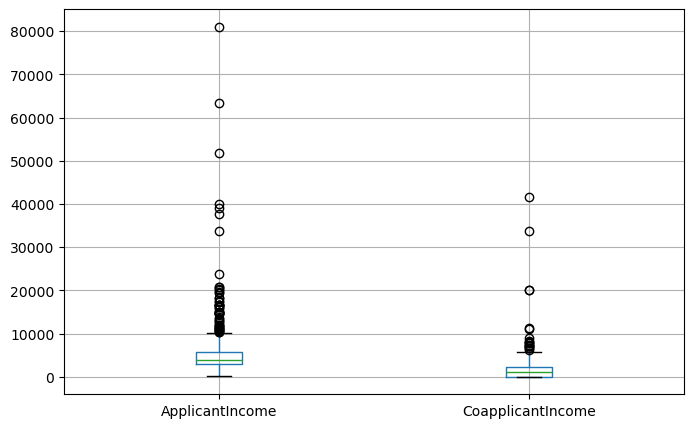

In [12]:
df[['ApplicantIncome', 'CoapplicantIncome']].boxplot(figsize=(8,5))

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import pandas as pd

# Assuming df is already loaded
threshold = 3
z_scores = stats.zscore(df[['ApplicantIncome', 'CoapplicantIncome']], nan_policy='omit')
mask = (np.abs(z_scores) < threshold).all(axis=1)
df_clean = df[mask]
df_clean.shape

(600, 13)

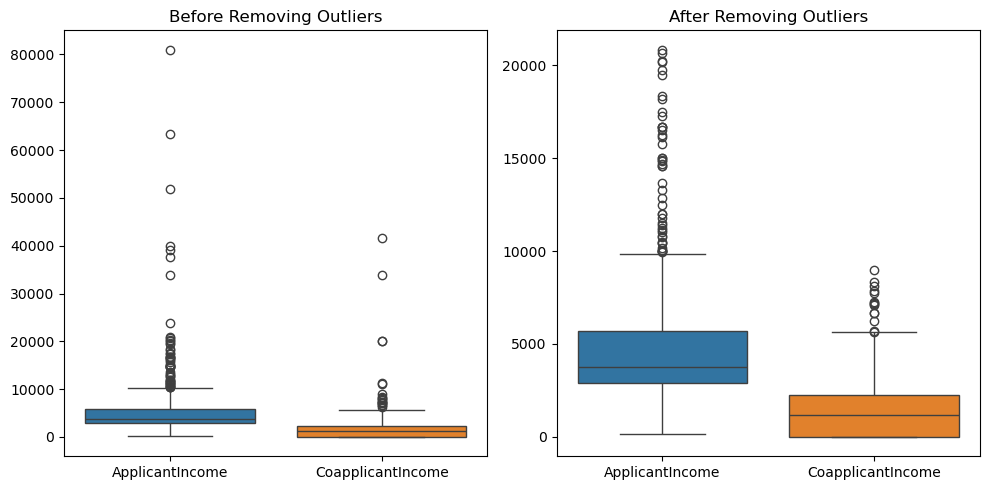

In [14]:
# Compare boxplots before and after removing outliers
plt.figure(figsize=(10,5))

# Before cleaning
plt.subplot(1,2,1)
sns.boxplot(data=df[['ApplicantIncome', 'CoapplicantIncome']])
plt.title('Before Removing Outliers')

# After cleaning
plt.subplot(1,2,2)
sns.boxplot(data=df_clean[['ApplicantIncome', 'CoapplicantIncome']])
plt.title('After Removing Outliers')

plt.tight_layout()
plt.show()


In [15]:
# 2 way to detect outliers 
outliers=[]
a=df['ApplicantIncome']      
def detect_outliers_Zscore(x):
    thres = 3
    mean = np.mean(x)
    std = np.std(x)
    for i in x:
        z_score = (i-mean)/std
        if (np.abs(z_score)>thres):
            outliers.append(i)
    return outliers
sample_outliers = detect_outliers_Zscore(df['ApplicantIncome'])
print(sample_outliers)

[23803, 39999, 51763, 33846, 39147, 63337, 81000, 37719]


In [ ]:
print(len(sample_outliers))
for ab in outliers:
    df.drop(df.loc[df[a.name]==ab].index, inplace = True)
df.shape

8


(606, 13)

In [17]:
# Columns to check
cols = ['ApplicantIncome', 'CoapplicantIncome']
threshold = 3

# Compute Z-scores and convert to DataFrame
z_scores = pd.DataFrame(stats.zscore(df[cols], nan_policy='omit'), columns=cols)

# 1️⃣ Continuous outlier percentage per column
for col in cols:
    percentage = (z_scores[col].abs() > threshold).mean() * 100
    print(f"{col}: {percentage:.2f}% outliers")

# 2️⃣ Continuous overall outlier percentage (any column)
overall_percentage = (z_scores.abs() > threshold).any(axis=1).mean() * 100
print(f"\nOverall Dataset Outlier Percentage: {overall_percentage:.2f}%")

ApplicantIncome: 2.81% outliers
CoapplicantIncome: 0.99% outliers

Overall Dataset Outlier Percentage: 3.80%
